# Machine Learning Session

In [ ]:
# ===== IMPORT ALL LIBRARIES FOR THE NOTEBOOK =====

# Data manipulation
import numpy as np
import pandas as pd

# Plots
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor, plot_tree as xgb_plot_tree

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN


## Data Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
india_AQ = pd.read_excel("/content/drive/MyDrive/Hackathon Session/Data/who_ambient_air_quality_database_version_2024_(v6.1).xlsx", sheet_name="Update 2024 (V6.1)")

In [ ]:
india_AQ.head()

,who_region,iso3,country_name,city,year,version,pm10_concentration,pm25_concentration,no2_concentration,pm10_tempcov,pm25_tempcov,no2_tempcov,type_of_stations,reference,web_link,population,population_source,latitude,longitude,who_ms
0,4_Eur,ESP,Spain,A Coruna/ESP,2013.0,"V4.0 (2018), V4.0 (2018), V4.0 (2018), V4.0 (2...",23.238,11.491,28.841,87.0,46.0,93.0,"Urban, Urban, Suburban",NaN,NaN,246146.0,"manual, manual, manual, manual",43.367900,-8.418571,1
1,4_Eur,ESP,Spain,A Coruna/ESP,2014.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023)",27.476,15.878,19.575,96.0,88.0,95.0,"Urban, Urban, Suburban",NaN,NaN,247604.0,NaN,43.368033,-8.418233,1
2,4_Eur,ESP,Spain,A Coruna/ESP,2015.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023), V6.0...",25.515,14.004,22.731,98.0,71.0,98.0,"Urban, Urban, Suburban, Suburban",NaN,NaN,247604.0,NaN,43.370375,-8.422900,1
3,4_Eur,ESP,Spain,A Coruna/ESP,2016.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023), V6.0...",23.057,13.160,20.204,98.0,98.0,98.0,"Urban, Urban, Suburban, Suburban",NaN,NaN,247604.0,NaN,43.370375,-8.422900,1
4,4_Eur,ESP,Spain,A Coruna/ESP,2017.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023), V6.0...",26.849,14.114,21.543,97.0,97.0,98.0,"Urban, Urban, Suburban, Suburban",NaN,NaN,247604.0,NaN,43.370375,-8.422900,1


In [ ]:
len(india_AQ)

40098

In [ ]:
(india_AQ.isnull().sum()/len(india_AQ))*100

,0
who_region,0.000000
iso3,0.000000
country_name,0.000000
city,0.000000
year,0.007482
version,0.000000
pm10_concentration,28.495187
pm25_concentration,45.807771
no2_concentration,32.829568
pm10_tempcov,44.129383


In [ ]:
india_AQ['reference'].value_counts()

,count
reference,
Environmental Protection Agency,2172
European Environmental Agency,894
"Environmental Protection Agency, Environmental Protection Agency",648
"Environmental Protection Agency, Environmental Protection Agency, Environmental Protection Agency",360
Clean Air Asia,275
...,...
"Ministry of Environmental Protection, Ministry of Environmental Protection, Ministry of Environmental Protection, Ministry of Environmental Protection, Ministry of Environmental Protection, Ministry of Environmental Protection",1
"South African Air Quality Information System, South African Air Quality Information System, South African Air Quality Information System, South African Air Quality Information System, South African Air Quality Information System, data received upon request November 2015), South African Air Quality Information System, data received upon request November 2015), South African Air Quality Information System, data received upon request November 2015), South African Air Quality Information System, data received upon request November 2015), South African Air Quality Information System, data received upon request November 2015), South African Air Quality Information System, data received upon request November 2015), South African Air Quality Information System, South African Air Quality Information System, South African Air Quality Information System, South African Air Quality Information System, South African Air Quality Information System, South African Air Quality Information System",1
"Bhutan-State-of-Environment-Report-2016.pdf, Brief report on air quality status over 2011-2012, Climate Change Division, National environment commission, 2017, Brief report on air quality status over 2011-2012, Climate Change Division, National environment commission, 2013, Brief report on air quality status over 2011-2012, Climate Change Division, National environment commission, 2015, Brief report on air quality status over 2011-2012, Climate Change Division, National environment commission, 2016, Brief report on air quality status over 2011-2012, Climate Change Division, National environment commission, 2014",1


In [ ]:
india_AQ['web_link'].value_counts()

,count
web_link,
https://www.eea.europa.eu/themes/air/explore-air-pollution-data,893
https://www.bafu.admin.ch/bafu/en/home/topics/air/state/data/national-air-pollution-monitoring-network--nabel-.html; data: https://www.arias.ch/ibonline/ib_online.php,138
"https://www.eea.europa.eu/themes/air/explore-air-pollution-data, https://www.eea.europa.eu/themes/air/explore-air-pollution-data",134
https://saaqis.environment.gov.za/,50
"https://www.eea.europa.eu/themes/air/explore-air-pollution-data, https://www.eea.europa.eu/themes/air/explore-air-pollution-data, https://www.eea.europa.eu/themes/air/explore-air-pollution-data",33
...,...
"https://saaqis.environment.gov.za/, https://saaqis.environment.gov.za/, https://saaqis.environment.gov.za/, https://saaqis.environment.gov.za/, http://www.saaqis.org.za/, http://www.saaqis.org.za/, http://www.saaqis.org.za/, http://www.saaqis.org.za/, http://www.saaqis.org.za/, http://www.saaqis.org.za/, http://www.saaqis.org.za/, http://www.saaqis.org.za/, http://www.saaqis.org.za/, http://www.saaqis.org.za/, http://www.saaqis.org.za/, http://www.saaqis.org.za/",1
"http://www.saaqis.org.za/, http://www.saaqis.org.za/, http://www.saaqis.org.za/, http://www.saaqis.org.za/, http://www.saaqis.org.za/, http://www.saaqis.org.za/, https://saaqis.environment.gov.za/, https://saaqis.environment.gov.za/, https://saaqis.environment.gov.za/, https://saaqis.environment.gov.za/",1
"Office of Environment and Heritage NSW Government, http://www.environment.nsw.gov.au/resources/aqms/150004nswairqual14.pdf",1


In [ ]:
india_AQ['population_source'].value_counts()

,count
population_source,
old database,2153
Imputed_from_UNWUP2018,1710
"old database, old database",1525
"Imputed_from_UNWUP2018, Imputed_from_UNWUP2018",1087
city_pop,1013
...,...
"https://u.ae/en/about-the-uae/the-seven-emirates/ras-al-khaimah, https://u.ae/en/about-the-uae/the-seven-emirates/ras-al-khaimah",1
"old database, old database, old database, manual",1
"UN 2015, UN 2015, UN_pop, UN_pop",1


In [ ]:
from sklearn.impute import KNNImputer

# 1. Drop irrelevant columns
cols_to_drop = ['reference', 'web_link', 'population_source']
india_AQ.drop(columns=cols_to_drop, inplace=True)

In [ ]:
(india_AQ.isnull().sum()/len(india_AQ))*100

,0
who_region,0.000000
iso3,0.000000
country_name,0.000000
city,0.000000
year,0.007482
version,0.000000
pm10_concentration,28.495187
pm25_concentration,45.807771
no2_concentration,32.829568
pm10_tempcov,44.129383


In [ ]:
india_AQ['year'].value_counts()

,count
year,
2018.0,4678
2019.0,4594
2016.0,4131
2015.0,4096
2020.0,3983
2013.0,3869
2017.0,3820
2014.0,3460
2010.0,2878


In [ ]:
len(india_AQ)

40098

In [ ]:
india_AQ = india_AQ.dropna(subset=["year"])

In [ ]:
len(india_AQ)

40095

In [ ]:
india_AQ['type_of_stations'].value_counts()

,count
type_of_stations,
Urban,7841
Rural,5272
Suburban,4631
"Urban, Urban",1778
"Urban, Urban, Urban",637
...,...
"Suburban, Suburban, Suburban, Urban, Suburban, Urban, Urban",1
"Urban, Urban, Urban, Urban, Urban, Urban, Urban, Urban, Urban, Urban, Urban, Urban, Urban, Urban, Urban, Urban, Urban, Urban",1
"Suburban, Suburban, Urban, Suburban, Urban",1


In [ ]:
def clean_station_type(station_str):
    if pd.isna(station_str):
        return "Unknown"
    # Split on commas, strip spaces, get unique values
    types = list(set([t.strip() for t in station_str.split(",")]))

    return types[0]

# Apply cleaning
india_AQ["type_of_stations"] = india_AQ["type_of_stations"].apply(clean_station_type)

india_AQ["type_of_stations"].value_counts()

,count
type_of_stations,
Unknown,16764
Urban,10738
Suburban,6403
Rural,5917
Background,76
Traffic,75
Residential And Commercial Area,69
Industrial,21
Urban Traffic,21


In [ ]:
(india_AQ.isnull().sum()/len(india_AQ))*100

,0
who_region,0.000000
iso3,0.000000
country_name,0.000000
city,0.000000
year,0.000000
version,0.000000
pm10_concentration,28.489837
pm25_concentration,45.806210
no2_concentration,32.824542
pm10_tempcov,44.125203


In [ ]:
# 4. Apply KNN Imputer for pollutants, tempcov, and population
knn_features = ['pm10_concentration', 'pm25_concentration', 'no2_concentration',
                'pm10_tempcov', 'pm25_tempcov', 'no2_tempcov', 'population']

# Ensure all features are present
knn_features = [col for col in knn_features if col in india_AQ.columns]

# Apply KNN Imputation
imputer = KNNImputer(n_neighbors=5)
india_AQ[knn_features] = imputer.fit_transform(india_AQ[knn_features])

# 5. Confirm cleanup
print("Missing values after cleaning:")
print(india_AQ.isnull().sum())

Missing values after cleaning:
who_region            0
iso3                  0
country_name          0
city                  0
year                  0
version               0
pm10_concentration    0
pm25_concentration    0
no2_concentration     0
pm10_tempcov          0
pm25_tempcov          0
no2_tempcov           0
type_of_stations      0
population            0
latitude              0
longitude             0
who_ms                0
dtype: int64


Handle Categorical Data

In [ ]:
# One-hot encode WHO region
india_AQ = pd.get_dummies(india_AQ, columns=['who_region'])

# Simplify type_of_stations if multi-labeled
india_AQ = pd.get_dummies(india_AQ, columns=['type_of_stations'])

In [ ]:
india_AQ.head()

,iso3,country_name,city,year,version,pm10_concentration,pm25_concentration,no2_concentration,pm10_tempcov,pm25_tempcov,...,type_of_stations_Residential,type_of_stations_Residential - industrial,type_of_stations_Residential And Commercial Area,type_of_stations_Rural,type_of_stations_Suburban,type_of_stations_Traffic,type_of_stations_Unknown,type_of_stations_Urban,type_of_stations_Urban Traffic,type_of_stations_Urban Traffic/Residential And Commercial Area
0,ESP,Spain,A Coruna/ESP,2013.0,"V4.0 (2018), V4.0 (2018), V4.0 (2018), V4.0 (2...",23.238,11.491,28.841,87.0,46.0,...,False,False,False,False,True,False,False,False,False,False
1,ESP,Spain,A Coruna/ESP,2014.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023)",27.476,15.878,19.575,96.0,88.0,...,False,False,False,False,True,False,False,False,False,False
2,ESP,Spain,A Coruna/ESP,2015.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023), V6.0...",25.515,14.004,22.731,98.0,71.0,...,False,False,False,False,True,False,False,False,False,False
3,ESP,Spain,A Coruna/ESP,2016.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023), V6.0...",23.057,13.160,20.204,98.0,98.0,...,False,False,False,False,True,False,False,False,False,False
4,ESP,Spain,A Coruna/ESP,2017.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023), V6.0...",26.849,14.114,21.543,97.0,97.0,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
india_AQ.drop('version', axis=1, inplace=True)

In [ ]:
india_AQ.drop('iso3', axis=1, inplace=True)
india_AQ.drop('city', axis=1, inplace=True)

In [ ]:
for col in india_AQ.columns:
  if india_AQ[col].dtype == 'object':
    print(col)

country_name


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder instance
le = LabelEncoder()

india_AQ['country_name'] = le.fit_transform(india_AQ['country_name'])

Normalize / Scale Features

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale numeric columns
numeric_cols = india_AQ.columns

scaler = StandardScaler()
india_AQ[numeric_cols] = scaler.fit_transform(india_AQ[numeric_cols])

 Train-Test Split (for Regression)

In [ ]:
from sklearn.model_selection import train_test_split

# Example: predict PM2.5
X = india_AQ.drop(columns=['pm25_concentration'])
y = india_AQ['pm25_concentration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Supervised Learning

Single Linear Regression

- Applying Single Linear Regression
- Applying Polynomial Regression
- Evaluating our models


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## Simple Linear Regression

Mean Squared Error: 0.4190674218078869
R² Score: 0.6112593841838435


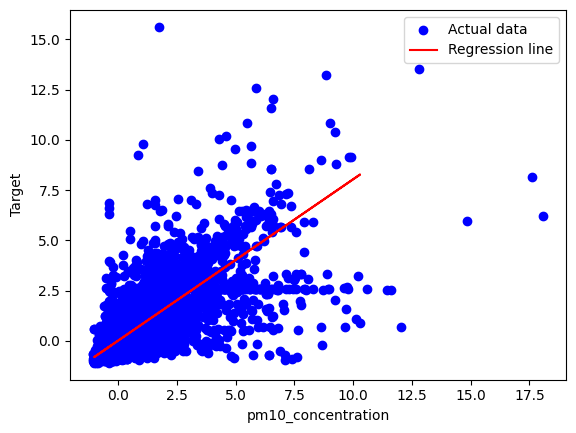

In [ ]:
# Example data (X must be 2D for sklearn)
X_train_simple = X_train['pm10_concentration'].values.reshape(-1,1)
y_train_simple = y_train

X_test_simple = X_test['pm10_concentration'].values.reshape(-1,1)

# Create and fit the model
model = LinearRegression()
model.fit(X_train_simple, y_train_simple)

# Predictions
y_pred_simple = model.predict(X_test_simple)

# Metrics
mse = mean_squared_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

# Plot
plt.scatter(X_train_simple, y_train_simple, color='blue', label="Actual data")
plt.plot(X_test_simple, y_pred_simple, color='red', label="Regression line")
plt.xlabel("pm10_concentration")
plt.ylabel("Target")
plt.legend()
plt.show()

## Multiple Linear Regression

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

def evaluate_model(model, name):

    # Train
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name}:")
    print("  MSE:", mse)
    print("  R² :", r2)
    print("-" * 40)

In [ ]:
# Multiple Linear Regression
MLR_model = LinearRegression()
evaluate_model(MLR_model, "Multiple Linear Regression")

Multiple Linear Regression:
  MSE: 0.3343824372653066
  R² : 0.6898159393544722
----------------------------------------


In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
evaluate_model(dt_model, "Decision Tree Regressor")

Decision Tree Regressor:
  MSE: 0.3281220787906707
  R² : 0.6956232521686272
----------------------------------------


In [ ]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
evaluate_model(rf_model, "Random Forest Regressor")

Random Forest Regressor:
  MSE: 0.19061618213518755
  R² : 0.823178209109924
----------------------------------------


In [ ]:
# XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
evaluate_model(xgb_model, "XGBoost Regressor")

XGBoost Regressor:
  MSE: 0.19470338135720186
  R² : 0.8193867897347917
----------------------------------------


## Unsupervised Learning
### Clustering

## K-means steps


1.   define k
2.   randomly place k centroids
3.   assign each point to a cluster( the cluster of the closest centroid)
4.   update the centroids(the new centroid is the mean of the cluster)
5.   repeat from step 3
6.   stop when the centroids no longer change
<img src="https://files.realpython.com/media/centroids_iterations.247379590275.gif" width="750" align="center">



Inertia by k: {1: 120285.00000000028, 2: 70880.7180971715, 3: 48552.95822679933, 4: 37916.462571526645, 5: 28660.762691440883, 6: 22482.216717340132, 7: 18865.27210818259, 8: 16694.514204965377, 9: 15134.16263366148}


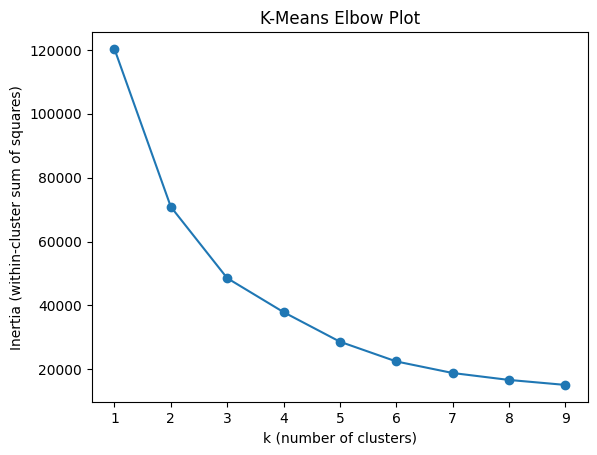

In [ ]:
# --- KMeans elbow method (fixed & robust) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1) Pick numeric pollution features (fallback to any numeric if some are missing)
preferred_cols = ['pm10_concentration', 'pm25_concentration', 'no2_concentration']

# 2) Build X: numeric only, simple median imputation
X = india_AQ[preferred_cols].copy()
X = X.fillna(X.median(numeric_only=True))

# 3) Scale (important for KMeans)
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# 4) Elbow: inertia for k=1..9
inertias = []
mapping = {}
K = range(1, 10)
for k in K:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(Xs)
    inertias.append(km.inertia_)
    mapping[k] = km.inertia_

print("Inertia by k:", mapping)

# 5) Plot elbow
plt.figure()
plt.plot(list(K), inertias, marker='o')
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("K-Means Elbow Plot")
plt.xticks(list(K))
plt.show()


In [ ]:
from sklearn.cluster import KMeans

# Fit KMeans with chosen k
best_k = 3
km = KMeans(n_clusters=best_k, n_init=50, random_state=42)
labels_km = km.fit_predict(Xs)

# Add cluster labels to your dataframe
india_AQ["cluster"] = labels_km

india_AQ.head()

,country_name,year,pm10_concentration,pm25_concentration,no2_concentration,pm10_tempcov,pm25_tempcov,no2_tempcov,population,latitude,...,type_of_stations_Residential - industrial,type_of_stations_Residential And Commercial Area,type_of_stations_Rural,type_of_stations_Suburban,type_of_stations_Traffic,type_of_stations_Unknown,type_of_stations_Urban,type_of_stations_Urban Traffic,type_of_stations_Urban Traffic/Residential And Commercial Area,cluster
0,1.093533,-1.037230,-0.279412,-0.398797,0.377562,0.001621,-1.829081,0.267971,-0.323336,0.204914,...,-0.004994,-0.04152,-0.416081,2.293885,-0.04329,-0.847661,-0.604792,-0.022892,-0.013214,0
1,1.093533,-0.716372,-0.128714,-0.106900,-0.002846,0.441110,0.150624,0.362805,-0.322559,0.204923,...,-0.004994,-0.04152,-0.416081,2.293885,-0.04329,-0.847661,-0.604792,-0.022892,-0.013214,0
2,1.093533,-0.395513,-0.198445,-0.231590,0.126721,0.538774,-0.650685,0.505057,-0.322559,0.205066,...,-0.004994,-0.04152,-0.416081,2.293885,-0.04329,-0.847661,-0.604792,-0.022892,-0.013214,0
3,1.093533,-0.074655,-0.285848,-0.287747,0.022977,0.538774,0.621982,0.505057,-0.322559,0.205066,...,-0.004994,-0.04152,-0.416081,2.293885,-0.04329,-0.847661,-0.604792,-0.022892,-0.013214,0
4,1.093533,0.246204,-0.151009,-0.224271,0.077948,0.489942,0.574846,0.505057,-0.322559,0.205066,...,-0.004994,-0.04152,-0.416081,2.293885,-0.04329,-0.847661,-0.604792,-0.022892,-0.013214,0


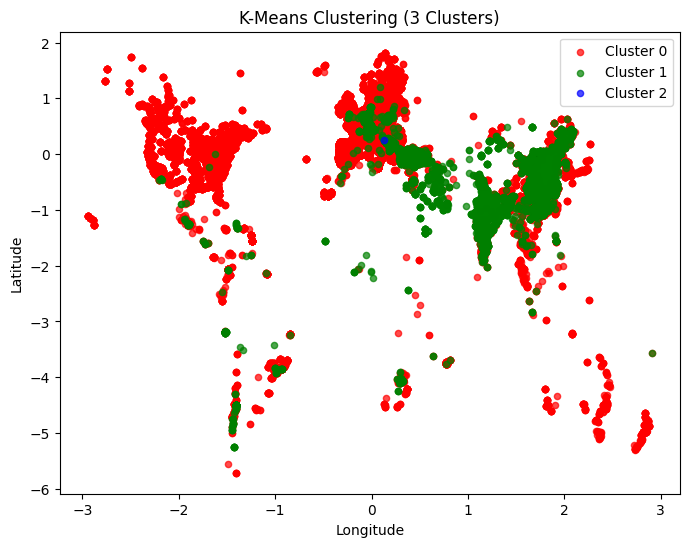

In [ ]:
import matplotlib.pyplot as plt

# Pick exactly three colors (one for each cluster)
colors = ['red', 'green', 'blue']

plt.figure(figsize=(8, 6))
for cluster_id in range(3):
    cluster_points = india_AQ[labels_km == cluster_id]
    plt.scatter(
        cluster_points["longitude"],
        cluster_points["latitude"],
        color=colors[cluster_id],
        label=f"Cluster {cluster_id}",
        s=20,
        alpha=0.7
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-Means Clustering (3 Clusters)")
plt.legend()
plt.show()

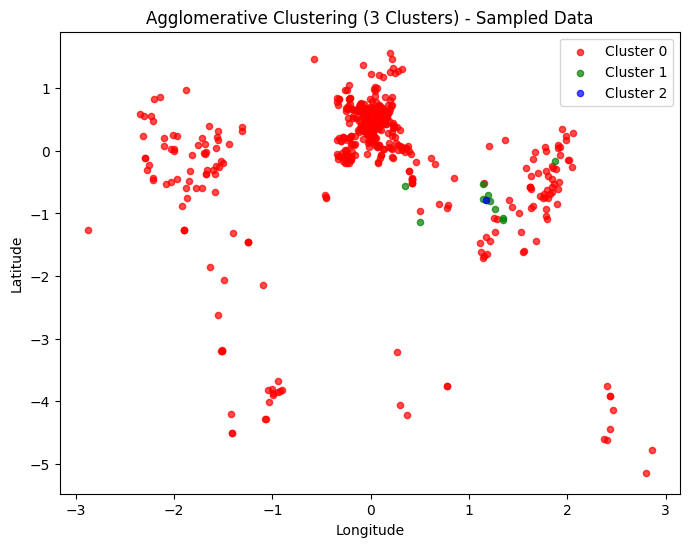

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

sample_df = india_AQ.sample(n=500, random_state=42)  # e.g., 500 points
Xs_sample = scaler.fit_transform(sample_df[preferred_cols])

# Fit Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=3, linkage="average")
labels_agg = agg.fit_predict(Xs_sample)

sample_df["cluster_agg"] = labels_agg

# --- Visualization: latitude vs longitude ---
colors = ['red', 'green', 'blue']

# Plot using sample_df only
plt.figure(figsize=(8, 6))
for cluster_id in range(3):
    cluster_points = sample_df[sample_df["cluster_agg"] == cluster_id]
    plt.scatter(
        cluster_points["longitude"],
        cluster_points["latitude"],
        color=colors[cluster_id],
        label=f"Cluster {cluster_id}",
        s=20,
        alpha=0.7
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Agglomerative Clustering (3 Clusters) - Sampled Data")
plt.legend()
plt.show()

DBscan DBSCAN (“deep scan”) + visualize

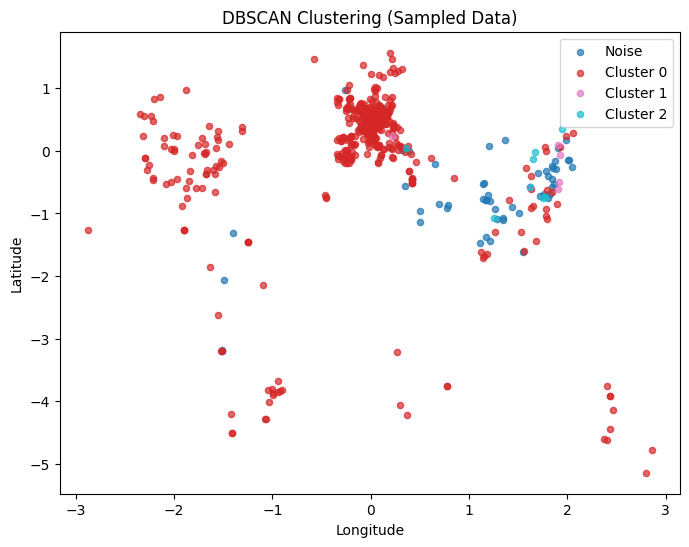

In [ ]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# Sample to avoid heavy runtime if dataset is large
sample_df = india_AQ.sample(n=500, random_state=42)
Xs_sample = scaler.fit_transform(sample_df[preferred_cols])

# Apply DBSCAN
db = DBSCAN(eps=0.5, min_samples=5)  # adjust eps for your data
labels_db = db.fit_predict(Xs_sample)

# Add labels to sample_df
sample_df["cluster_db"] = labels_db

# Prepare colors (DBSCAN may produce -1 for noise)
unique_labels = np.unique(labels_db)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

plt.figure(figsize=(8, 6))
for label, color in zip(unique_labels, colors):
    cluster_points = sample_df[sample_df["cluster_db"] == label]
    label_name = f"Cluster {label}" if label != -1 else "Noise"
    plt.scatter(
        cluster_points["longitude"],
        cluster_points["latitude"],
        color=color,
        label=label_name,
        s=20,
        alpha=0.7
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Clustering (Sampled Data)")
plt.legend()
plt.show()
